<a href="https://colab.research.google.com/github/Mohammed-Taher6705/jigsaw-puzzle-matching/blob/main/Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!git clone https://github.com/Mohammed-Taher6705/jigsaw-puzzle-matching.git


Cloning into 'jigsaw-puzzle-matching'...
remote: Enumerating objects: 1331, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 1331 (delta 17), reused 21 (delta 16), pack-reused 1308 (from 3)
Receiving objects: 100% (1331/1331), 368.58 MiB | 25.59 MiB/s, done.
Resolving deltas: 100% (90/90), done.


In [16]:
import zipfile
import os
import cv2
from glob import glob
import shutil
import matplotlib.pyplot as plt


In [17]:
zip_path = "/content/jigsaw-puzzle-matching/Dataset.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)
print("Folders inside extracted dataset:", os.listdir(extract_path))


Extracted to: /content
Folders inside extracted dataset: ['.config', 'Dataset', 'jigsaw-puzzle-matching', 'sample_data']


In [18]:
# Cell 2: detect dataset root that contains expected folders
expected = {"correct", "puzzle_2x2", "puzzle_4x4", "puzzle_8x8"}

def has_expected(root):
    if not os.path.isdir(root):
        return False
    entries = set([
        name for name in os.listdir(root)
        if os.path.isdir(os.path.join(root, name))
    ])
    return expected.issubset(entries)


EXTRACT_TO = "/content/Dataset"

candidates = [EXTRACT_TO] + [
    os.path.join(EXTRACT_TO, x)
    for x in os.listdir(EXTRACT_TO)
    if os.path.isdir(os.path.join(EXTRACT_TO, x))
]

BASE_PATH = None
for c in candidates:
    if has_expected(c):
        BASE_PATH = c
        break

if BASE_PATH is None:
    print("Could not find all expected folders (correct, puzzle_2x2, puzzle_4x4, puzzle_8x8).")
    print("Contents of extraction folder:")
    print(sorted(os.listdir(EXTRACT_TO)))
    raise FileNotFoundError("Please inspect the contents and ensure the zip contains the expected folders.")
else:
    print("Detected dataset BASE_PATH:", BASE_PATH)
    print("Contents:")
    print(sorted(os.listdir(BASE_PATH)))


Detected dataset BASE_PATH: /content/Dataset
Contents:
['correct', 'puzzle_2x2', 'puzzle_4x4', 'puzzle_8x8']


In [19]:
## CELL 3 — Load images from each folder (JPG only)
paths = {
    "correct":      os.path.join(BASE_PATH, "correct"),
    "puzzle_2x2":   os.path.join(BASE_PATH, "puzzle_2x2"),
    "puzzle_4x4":   os.path.join(BASE_PATH, "puzzle_4x4"),
    "puzzle_8x8":   os.path.join(BASE_PATH, "puzzle_8x8"),
}

def load_images_from_folder(folder_path):
    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")) + glob(os.path.join(folder_path, "*.png")))
    images = []
    for p in image_paths:
        img = cv2.imread(p)
        if img is not None:
            images.append((os.path.basename(p), img, p))
    return images

datasets = {}
for name, path in paths.items():
    if os.path.isdir(path):
        datasets[name] = load_images_from_folder(path)
    else:
        datasets[name] = []
    print(f"{name}: {len(datasets[name])} images loaded.")


correct: 110 images loaded.
puzzle_2x2: 110 images loaded.
puzzle_4x4: 110 images loaded.
puzzle_8x8: 110 images loaded.



Processing: correct
 sample: 0.png


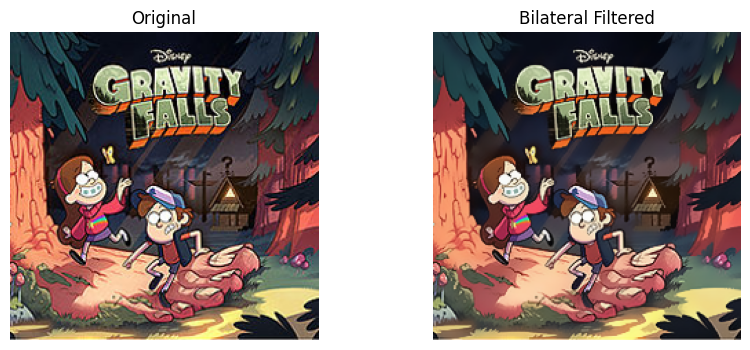


Processing: puzzle_2x2
 sample: 0.jpg


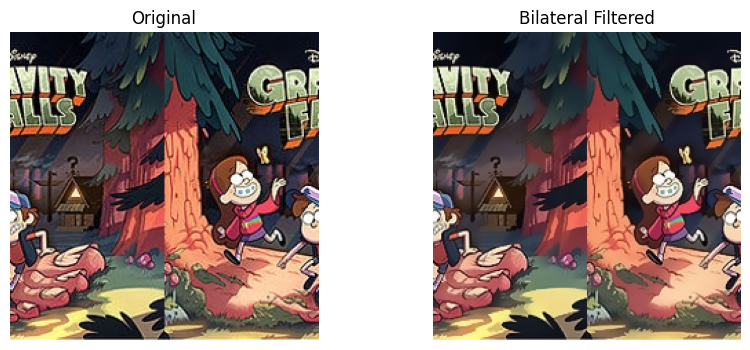


Processing: puzzle_4x4
 sample: 0.jpg


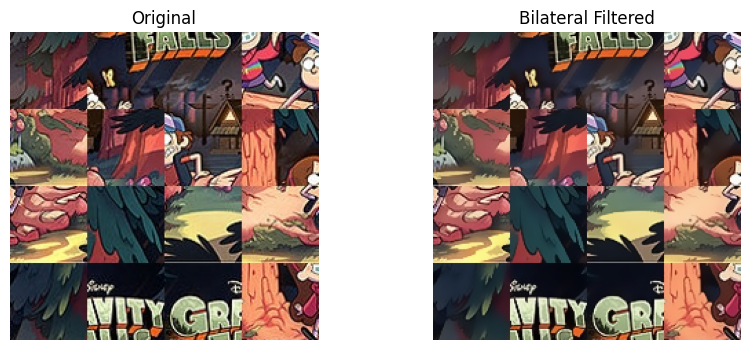


Processing: puzzle_8x8
 sample: 0.jpg


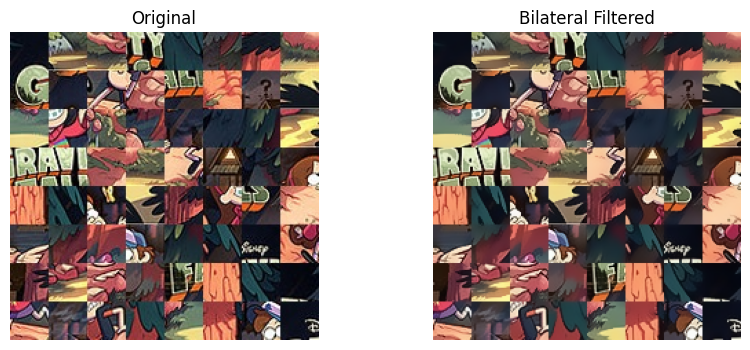

In [21]:
# Task-1: Bilateral Filter
DATASET_ROOT="/content/Dataset"
OUTPUT_ROOT="/content/denoised_dataset"
PUZZLE=["correct","puzzle_2x2","puzzle_4x4","puzzle_8x8"]

if os.path.exists(OUTPUT_ROOT):
    shutil.rmtree(OUTPUT_ROOT)
os.makedirs(OUTPUT_ROOT)

for split in PUZZLE:
    print("\nProcessing:", split)

    src = os.path.join(DATASET_ROOT, split)
    dst = os.path.join(OUTPUT_ROOT, split)
    os.makedirs(dst, exist_ok=True)

    files = sorted(glob(os.path.join(src, "*.jpg")) + glob(os.path.join(src, "*.png")))

    printed = False

    for p in files:
        img = cv2.imread(p)
        if img is None:
            continue

        denoised = cv2.bilateralFilter(img, d=9, sigmaColor=50, sigmaSpace=50)

        outp = os.path.join(dst, os.path.basename(p))
        cv2.imwrite(outp, denoised)

        if not printed:
          print(" sample:", os.path.basename(p))
          plt.figure(figsize=(10,4))
          plt.subplot(1,2,1)
          plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
          plt.title("Original")
          plt.axis("off")

          plt.subplot(1,2,2)
          plt.imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
          plt.title("Bilateral Filtered")
          plt.axis("off")

          plt.show()
          plt.close()

          printed = True


In [22]:
import shutil
import os

input_dir = "/content/denoised_dataset"
output_zip = "/content/denoised_dataset"

shutil.make_archive(
    base_name=output_zip,
    format="zip",
    root_dir=os.path.dirname(input_dir),
    base_dir=os.path.basename(input_dir)
)


'/content/denoised_dataset.zip'